Face ID range: 19 - 420021
Unique face IDs: 43754
Foreground pixels: 55954 (5.3%)
Top 10 IDs: [(np.int64(306001), np.int64(5)), (np.int64(4826), np.int64(4)), (np.int64(44751), np.int64(4)), (np.int64(70884), np.int64(4)), (np.int64(70917), np.int64(4)), (np.int64(76151), np.int64(4)), (np.int64(76266), np.int64(4)), (np.int64(78697), np.int64(4)), (np.int64(94610), np.int64(4)), (np.int64(94854), np.int64(4))]


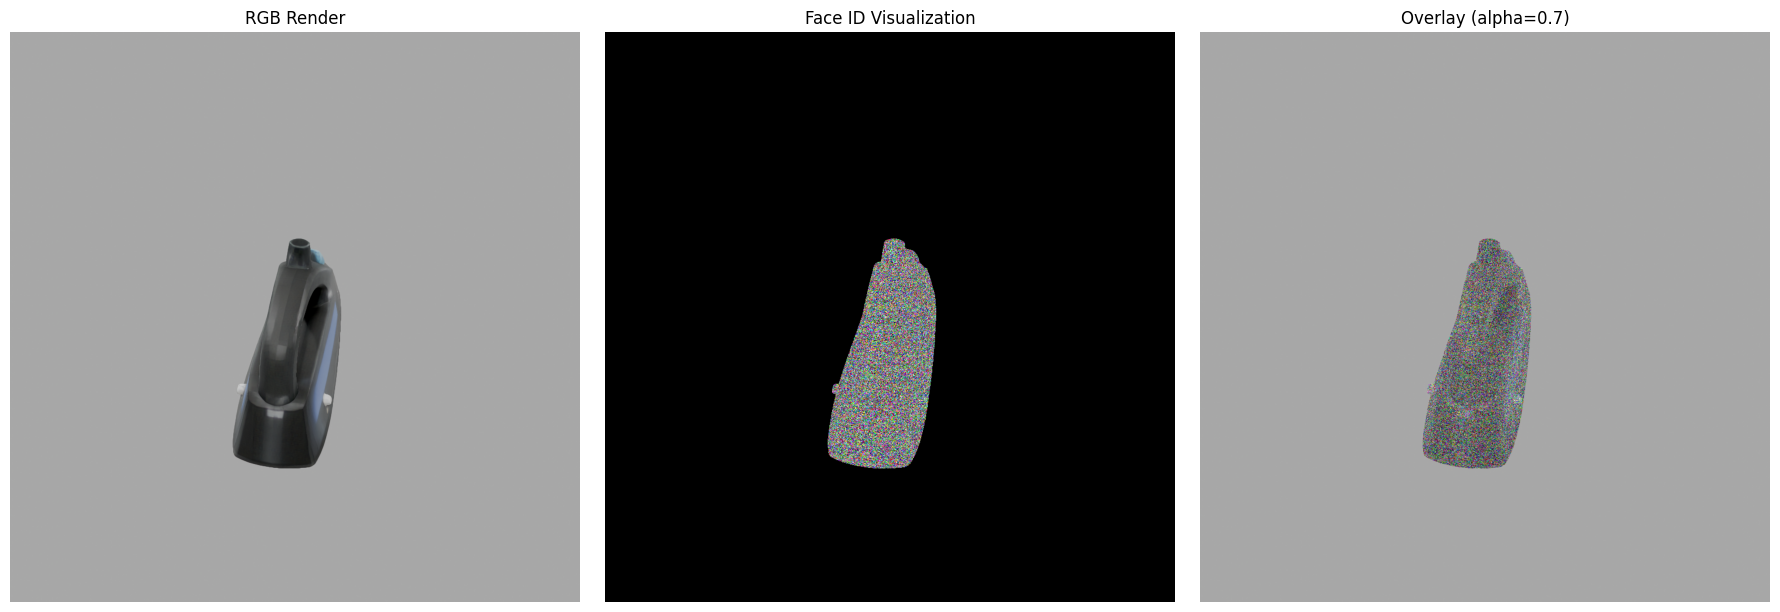

In [19]:
"""Visualize face IDs from Blender render output."""
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import OpenEXR
import Imath

ROOT = Path("objects/video_01/iron/renders")
VIEW_NAME = "az100_el+45"
RGB_PATH = ROOT / "rgb" / f"{VIEW_NAME}.png"
FACE_ID_PATH = ROOT / "face_id" / f"{VIEW_NAME}0001.exr"


def load_face_ids(exr_path: Path) -> np.ndarray:
    """
    Load face IDs from EXR file.
    
    Face IDs are stored as raw float values in the R channel.
    """
    exr = OpenEXR.InputFile(str(exr_path))
    header = exr.header()
    dw = header["dataWindow"]
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1

    pt = Imath.PixelType(Imath.PixelType.FLOAT)
    data = np.frombuffer(exr.channel("R", pt), dtype=np.float32)
    return data.reshape(height, width)


def ids_to_colors(ids: np.ndarray) -> np.ndarray:
    """
    Generate stable pseudo-random colors for each face ID.
    
    Uses hash mixing to ensure similar IDs get visually distinct colors.
    """
    x = ids.astype(np.uint32)
    x ^= x >> 16
    x *= np.uint32(0x7FEB352D)
    x ^= x >> 15
    x *= np.uint32(0x846CA68B)
    x ^= x >> 16

    return np.stack([
        (x & 0xFF).astype(np.uint8),
        ((x >> 8) & 0xFF).astype(np.uint8),
        ((x >> 16) & 0xFF).astype(np.uint8),
    ], axis=-1)


# Load data
rgb = np.array(Image.open(RGB_PATH).convert("RGB"))
face_ids_float = load_face_ids(FACE_ID_PATH)
face_ids = np.rint(face_ids_float).astype(np.int64)

# Validate dimensions
assert rgb.shape[:2] == face_ids.shape, (
    f"Shape mismatch: RGB {rgb.shape[:2]} vs face_id {face_ids.shape}"
)

# Background is where face_id == 0 (Blender renders background as 0)
is_foreground = face_ids > 0

# Statistics
fg_ids = face_ids[is_foreground]
unique_ids, counts = np.unique(fg_ids, return_counts=True)
top_ids = sorted(zip(unique_ids, counts), key=lambda x: -x[1])[:10]

print(f"Face ID range: {fg_ids.min()} - {fg_ids.max()}")
print(f"Unique face IDs: {len(unique_ids)}")
print(f"Foreground pixels: {is_foreground.sum()} ({is_foreground.mean()*100:.1f}%)")
print(f"Top 10 IDs: {top_ids}")

# Create visualization
face_vis = ids_to_colors(face_ids)
face_vis[~is_foreground] = 0

a = 0.70  # strength of face-id visualization on foreground pixels
rgb_f = rgb.astype(np.float32)
face_f = face_vis.astype(np.float32)

overlay = rgb_f.copy()
m = is_foreground  # (H, W) boolean

# Blend only where the mesh is visible
overlay[m] = (1.0 - a) * rgb_f[m] + a * face_f[m]
overlay = np.clip(overlay, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb)
axes[0].set_title("RGB Render")
axes[0].axis("off")

axes[1].imshow(face_vis)
axes[1].set_title("Face ID Visualization")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"Overlay (alpha={a})")
axes[2].axis("off")

plt.tight_layout()
plt.show()